# E-Bike Route Network Simulation

Author: Elaine Cao \
Email: yilingca@andrew.cmu.edu \
Mentor: Peter Zhang \
Date: April 26, 2025

## City Network & Distance Matrix

Generated a e-biking network for Nantong, China using OSMns with "bike" network type. By randomly selected 100 nodes, each e-bike parking spots is able to be represented. I have also generated a default **Distance Matrix** that calculates the **shortest path distance** (in minutes) between all parking spots bases on average biking speed. 

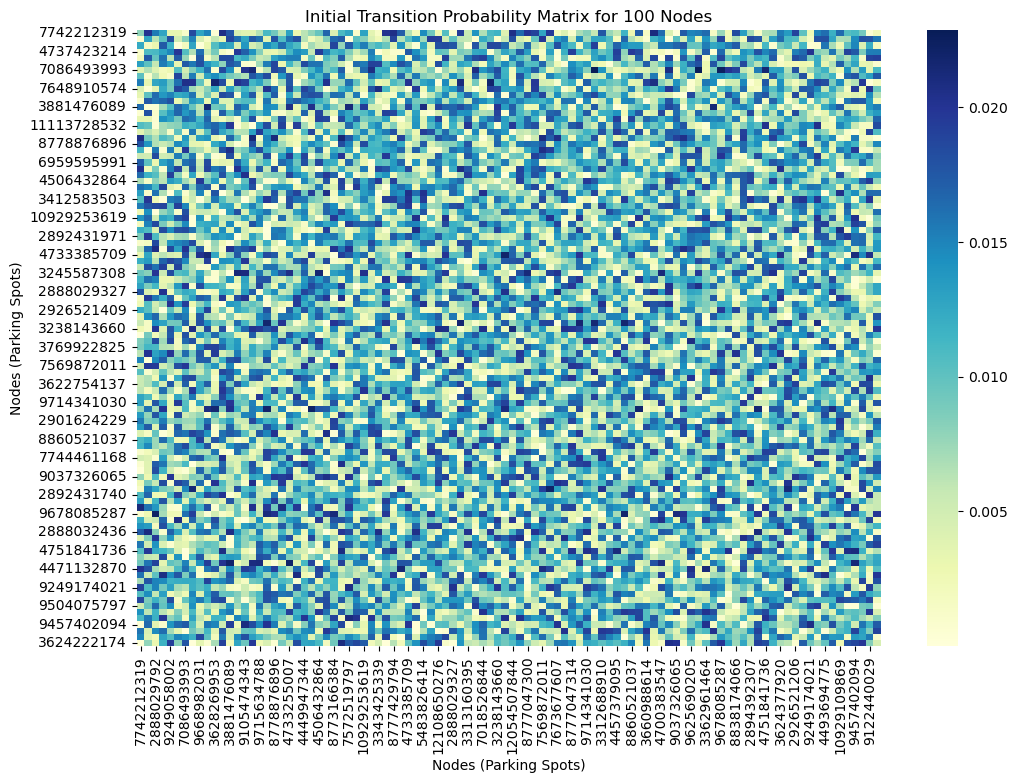

In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Generate City Network
place_name = "Nantong, China"
graph = ox.graph_from_place(place_name, network_type='bike')
graph = ox.project_graph(graph)  # Projected graph for accurate distance calculations

# Select 100 random nodes from the graph to act as parking spots
np.random.seed(42)
all_nodes = list(graph.nodes())
random_nodes = random.sample(all_nodes, 100)

# Generate Distance Matrix
# Calculate the shortest path length between each pair of nodes using network distance
distance_matrix = np.zeros((100, 100))
node_indices = {node: idx for idx, node in enumerate(random_nodes)}

for i, node1 in enumerate(random_nodes):
    for j, node2 in enumerate(random_nodes):
        if i != j:
            try:
                length = nx.shortest_path_length(graph, source=node1, target=node2, weight='length')
                distance_matrix[i, j] = length
            except nx.NetworkXNoPath:
                distance_matrix[i, j] = np.inf  # If there's no path between nodes

# Convert distance to time in minutes assuming average biking speed of 15 km/h (250 m/min)
distance_matrix = distance_matrix / 250

# Create Transition Probability Matrix
# For now, generate probabilities randomly; adjust later based on model
transition_matrix = np.random.rand(100, 100)
transition_matrix = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)  # Normalize rows

# Convert to DataFrame for better visualization
transition_df = pd.DataFrame(transition_matrix, index=random_nodes, columns=random_nodes)

# Visualize the Transition Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(transition_df, cmap="YlGnBu")
plt.title("Initial Transition Probability Matrix for 100 Nodes")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()


- X-axis: Destination parking spots (100 node IDs).
- Y-axis: Starting parking spots (100 node IDs).
- Color intensity: Transition probability from a starting node (row) to a destination node (column).

Each small square represents the probability that a bike moves from one parking spot to another during a 15-minute step.

**Summary and Interpretation**

The initial transition probability matrix are venly distributed across the node pairss. No clear "hotspots" where a particular transition is much stronger than others. Movement between locations is generally possible but with low individual probabilities. There is no obvious strong diagonal brightness, which indicates low probability of bikes staying at the same parking spot without moving. These finding is due to the initial setup and the randomization we include in our default noise. Since we do not have a data to start with, we need to start from a randomized data input matrix so that later on we can adjust it accordingly. 

In [15]:
transition_df.head()

,7742212319,4853299005,2888029792,4737423214,9249058002,1997709173,7086493993,4171423734,9668982031,7648910574,...,9249174021,4733254401,4493694775,9504075797,10929109869,3662541735,9457402094,6146838013,9122440029,3624222174
7742212319,0.007966,0.020220,0.015568,0.012733,0.003318,0.003318,0.001235,0.018422,0.012785,0.015060,...,0.002544,0.015170,0.016181,0.011937,0.016397,0.010502,0.011118,0.009093,0.000541,0.002295
4853299005,0.000631,0.012784,0.006315,0.010216,0.018230,0.005008,0.008243,0.015177,0.004596,0.001546,...,0.001870,0.018022,0.018087,0.012717,0.006810,0.007015,0.014582,0.018020,0.017819,0.015665
2888029792,0.012404,0.001626,0.003123,0.017360,0.011716,0.000178,0.001960,0.012819,0.000098,0.003107,...,0.000589,0.000722,0.015893,0.006959,0.002455,0.010090,0.014876,0.004170,0.012034,0.001649
4737423214,0.001052,0.010819,0.011008,0.012978,0.014784,0.019869,0.010512,0.006576,0.016190,0.005514,...,0.020167,0.008401,0.007574,0.015808,0.006939,0.018951,0.017478,0.008734,0.015288,0.015363
9249058002,0.001998,0.017490,0.009791,0.016015,0.006202,0.017354,0.007542,0.000210,0.017545,0.001769,...,0.008830,0.012017,0.005375,0.003645,0.008986,0.006847,0.011310,0.001506,0.018882,0.019111


## Markov Chain Simulation

In order to simulate a flow network so we can have a better adjusted matrix and trajectory of the e-bikes' route, we decided to use a **Markov Chain Model** to simulate one single e-bike's demand flow. 

Starting by randomly pick one of the 100 parking spots as the starting point, we simulate every every 5 minutes (one step), the bike moves to another parking spot. The next spot is randomly chosen based on the transition probabilities (specific to the current node). This process repeats for 15 steps → covering 75 minutes total.

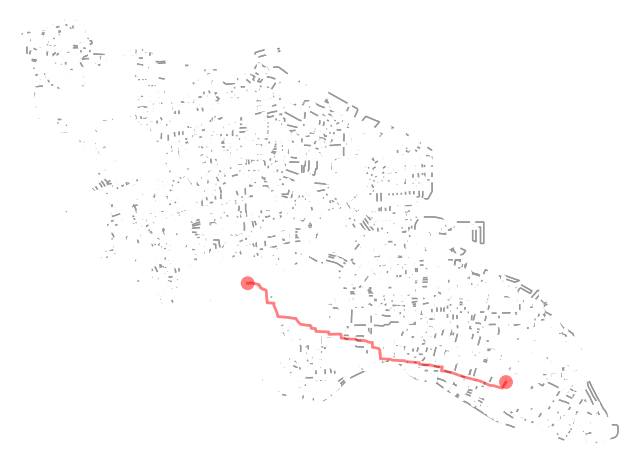

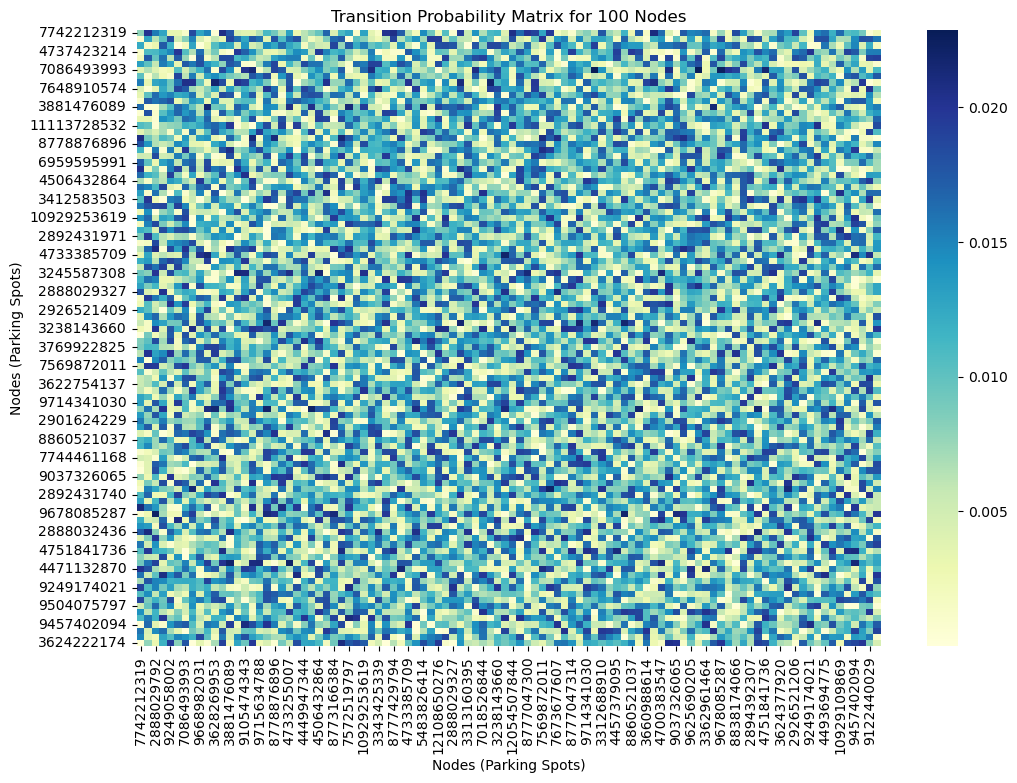

In [16]:
# Simulate Markov Chain
# Parameters for simulation
num_steps = 15  # Number of steps to simulate: 15 X 5 min = 75min
current_node = random.choice(random_nodes)  # Randomly choose a starting node
trajectory = [current_node]

for _ in range(num_steps):
    current_index = node_indices[current_node]
    next_node_index = np.random.choice(range(100), p=transition_matrix[current_index])
    current_node = random_nodes[next_node_index]
    trajectory.append(current_node)

# Visualize the Trajectory on the Graph
fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')

# Plot the nodes with trajectory highlighted
for i in range(1, len(trajectory)):
    node1 = trajectory[i - 1]
    node2 = trajectory[i]
    
    try:
        route = nx.shortest_path(graph, source=node1, target=node2, weight='length')
        ox.plot_graph_route(graph, route, route_color='red', route_linewidth=2, ax=ax, close=False)
    except nx.NetworkXNoPath:
        continue

# Visualize Transition Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(transition_df, cmap="YlGnBu")
plt.title("Transition Probability Matrix for 100 Nodes")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()

The Nantong city biking graph is plotted using OSMnx. Each movement between two parking spots is calculated using the shortest path on the road network. A red route connecting the two parking locations has shown a trajectory on the city map of this particular e-bike over 75 minutes. On the other hand, the transition probability matrix for the 100 nodes is visualized as a heatmap. This helps understand the underlying movement tendencies between locations. This new transition probability matrix does not seem to be a big of change from the initial matrix we have. The movements are still very spreadout due to the randomization we have in the process.


## Add factors that impacts transition matrix

In this section of the code, we simulate the behavior of an e-bike moving throughout Nantong city, adjusting its movement based on both time-of-day demand patterns and seasonal variations.

First, we define the time-of-day factors and seasonal factors. All weights are being assumed. With further analysis and research, we can adjust these factors accordingly. These represent how demand changes at different times and seasons — for example, bike movement is boosted during the morning peak (7 AM to 10 AM) by a factor of 1.5, while demand drops at night to 0.6. Since the simulation assumes it is summer, all movement probabilities are further multiplied by a season factor of 1.2 to represent higher biking activity.

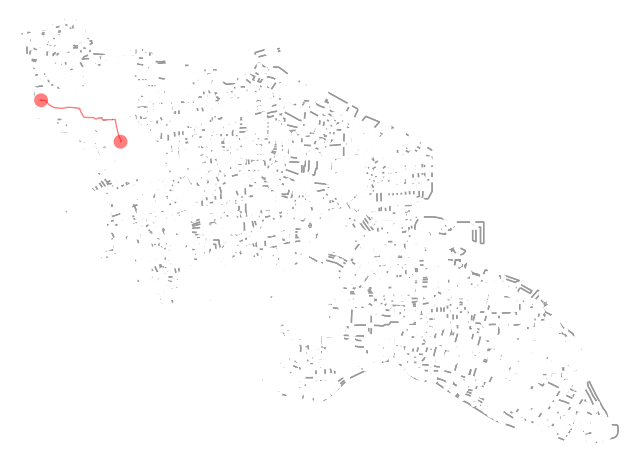

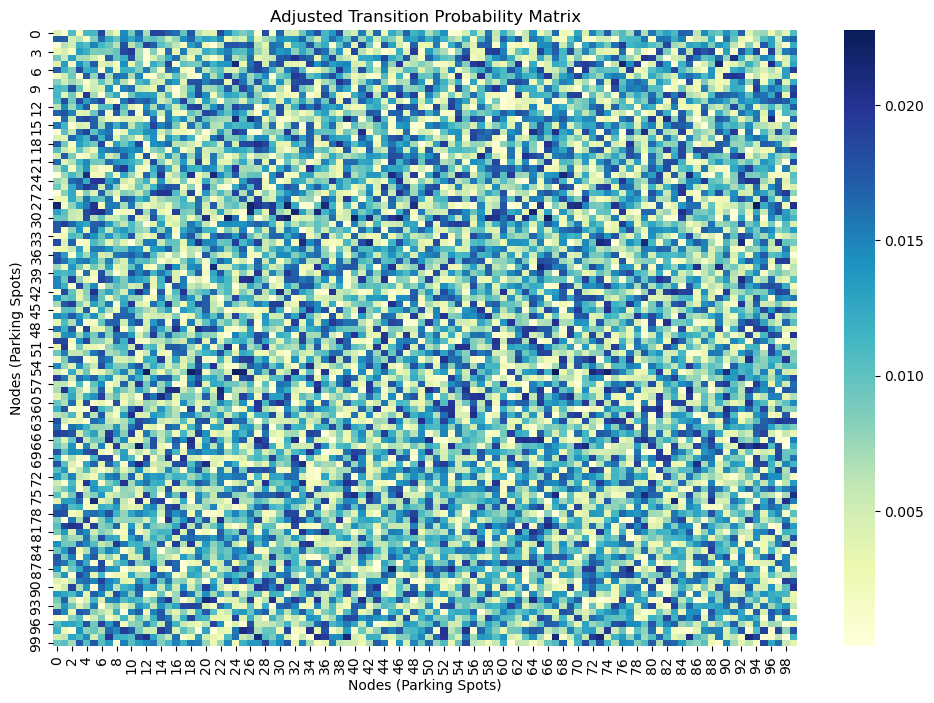

In [17]:
# Define Time-of-Day and Seasonal Factors
time_of_day_factors = {
    "early_morning": 0.5,   # Low demand (e.g., 12 AM - 6 AM)
    "morning_peak": 1.5,    # High demand (e.g., 7 AM - 10 AM)
    "midday": 1.0,          # Baseline (e.g., 11 AM - 4 PM)
    "evening_peak": 1.3,    # High demand (e.g., 5 PM - 8 PM)
    "night": 0.6            # Reduced usage (e.g., 9 PM - 11 PM)
}

seasonal_factors = {
    "winter": 0.7,
    "spring": 1.0,
    "summer": 1.2,
    "autumn": 0.9
}



# Input season for simulation
season = "summer"
season_factor = seasonal_factors[season]

# Generate Base Transition Probability Matrix
base_transition_matrix = np.random.rand(100, 100)
base_transition_matrix = base_transition_matrix / base_transition_matrix.sum(axis=1, keepdims=True)

# Function to adjust transition probabilities based on time of day
def adjust_transition_matrix(matrix, time_factor, season_factor):
    adjusted_matrix = matrix * time_factor * season_factor
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    return adjusted_matrix

# Simulate Markov Chain
num_steps = 288  # One day = 288 steps (5-minute intervals)

# Define time periods over the day
time_periods = {
    (0, 71): "early_morning",   # 12 AM - 6 AM
    (72, 119): "morning_peak",   # 7 AM - 10 AM
    (120, 239): "midday",        # 11 AM - 4 PM
    (240, 287): "evening_peak"   # 5 PM - 8 PM
}

# Initialize simulation variables
current_node = random.choice(random_nodes)
trajectory = [current_node]
transition_matrix = base_transition_matrix.copy()

for step in range(num_steps):
    # Determine the time of day for the current step
    for (start, end), period in time_periods.items():
        if start <= step <= end:
            time_factor = time_of_day_factors[period]
            break
    else:
        time_factor = time_of_day_factors["night"]  # Default to night if not in other ranges

    # Adjust the transition matrix based on time of day and season
    adjusted_matrix = adjust_transition_matrix(transition_matrix, time_factor, season_factor)
    
    current_index = node_indices[current_node]
    next_node_index = np.random.choice(range(100), p=adjusted_matrix[current_index])
    current_node = random_nodes[next_node_index]
    trajectory.append(current_node)

# Visualize the Simulation Trajectory
fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')

# Plot the nodes with trajectory highlighted
for i in range(1, len(trajectory)):
    node1 = trajectory[i - 1]
    node2 = trajectory[i]
    
    try:
        route = nx.shortest_path(graph, source=node1, target=node2, weight='length')
        ox.plot_graph_route(graph, route, route_color='red', route_linewidth=1, ax=ax, close=False)
    except nx.NetworkXNoPath:
        continue


# Visualize Transition Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pd.DataFrame(adjusted_matrix), cmap="YlGnBu")
plt.title("Adjusted Transition Probability Matrix")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()

Another base transition probability matrix is being generated — a 100x100 matrix where each row represents the probability distribution for a bike at a particular node to move to other nodes. This base matrix is normalized so that probabilities across each row sum to 1. Depending on whether it is early morning, morning peak, midday, evening peak, or night, the matrix is scaled accordingly. This makes the simulation adapt more to realistic changing city dynamics: bikes are much more active during peak hours, and less so during the night.

The city map visualization shows an individual e-bike’s realistic journey across the urban landscape, while the adjusted heatmap reflects global movement probabilities during that simulation phase. By adjusting for time-of-day and season, the model captures the fact that human biking behavior is not constant but cooperated with daily routines and weather seasons. These factors can also be inputed or adjusted with further analysis.

## Change In Transition Matrix

For below entire selection, we implemented the simulation model for e-bike movements across Nantong city by incorporating both distance-awareness and environmental demand features like time of day, seasonality, and location type.

In [18]:
from scipy.special import rel_entr

def generate_adjusted_transition_matrix(distance_matrix, kl_threshold=0.5):
    # Step 1: Create inverse-distance matrix
    inv_distances = 1 / (distance_matrix + 1e-6)
    np.fill_diagonal(inv_distances, 0)

    row_sums = inv_distances.sum(axis=1, keepdims=True)
    # Avoid division by zero
    inv_prob_matrix = np.divide(
        inv_distances,
        row_sums,
        out=np.zeros_like(inv_distances),  # fallback if divide-by-zero
        where=row_sums != 0
    )

    # Replace zero-probability rows with uniform distribution (optional fallback)
    for i in range(inv_prob_matrix.shape[0]):
        if inv_prob_matrix[i].sum() == 0:
            inv_prob_matrix[i] = np.ones(inv_prob_matrix.shape[1]) / inv_prob_matrix.shape[1]

    # Generate initial random transition matrix
    random_matrix = np.random.rand(distance_matrix.shape[0], distance_matrix.shape[1])
    random_matrix = random_matrix / random_matrix.sum(axis=1, keepdims=True)

    # Compute KL divergence row-wise and blend
    kl_divs = np.sum(rel_entr(random_matrix, inv_prob_matrix), axis=1)

    adjusted_matrix = np.copy(random_matrix)
    for i in range(len(kl_divs)):
        if kl_divs[i] > kl_threshold:
            adjusted_matrix[i] = inv_prob_matrix[i]

    # Normalize again for numerical safety
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    return adjusted_matrix

We first generated a distance-aware transition matrix by inversely weighting the distance between nodes (closer parking spots receive higher transition probabilities) and using KL divergence to blend random variability with distance bias. Specifically, for each node, if the random transition pattern deviates too much (measured by KL divergence) from the ideal distance-based behavior, the code replaces that node's transition distribution with the distance-based one to maintain realism.

## Adjuested Batch Simulation

In [19]:
def generate_mock_environmental_data(num_nodes=100, season="summer", time_period="morning_peak"):
    """
    Create synthetic environmental features including seasonal factor, time factor, and location type.
    """
    # Season effects (baseline demand multiplier)
    season_factor = {
        "winter": 0.7,
        "spring": 1.0,
        "summer": 1.2,
        "autumn": 0.9
    }

    # Time-of-day effect
    time_of_day_factor = {
        "early_morning": 0.5,
        "morning_peak": 1.5,
        "midday": 1.0,
        "evening_peak": 1.3,
        "night": 0.6
    }

    # Randomly assign location type: business, college, subway, residential
    location_types = np.random.choice(["business", "college", "subway", "residential"], size=num_nodes)
    location_factor_map = {
        "business": 1.5,
        "college": 1.3,
        "subway": 1.4,
        "residential": 1.0
    }
    location_factors = np.array([location_factor_map[loc] for loc in location_types])

    # Assemble features
    seasonal = np.full(num_nodes, season_factor[season])
    time_of_day = np.full(num_nodes, time_of_day_factor[time_period])
    location = location_factors

    # Combine into design matrix
    X = np.column_stack([seasonal, time_of_day, location])
    return X

# Updated node demand prediction using new features
def predict_node_demand(season, time_period, num_nodes=100):
    X = generate_mock_environmental_data(num_nodes=num_nodes, season=season, time_period=time_period)
    beta = np.array([1.0, 1.2, 1.5])  # weights for season, time, location type
    y_pred = X @ beta + np.random.randn(num_nodes) * 0.2  # small noise
    y_pred = np.maximum(y_pred, 0.1)
    demand_normalized = y_pred / y_pred.sum()
    return demand_normalized

Then we also incorperated the environmental demand data like what we have done before. Each parking spot is assigned a random location type (business district, college, subway station, or residential area), and factors are applied based on both season (e.g., summer leads to higher demand than winter) and time of day (e.g., morning peak vs night). Note that for a more precise implementation, we further need to adjust the location factor by explicitly assigning each node to the true location type instead of randomly assigning it. These factors are combined into a feature matrix, and using predefined weights, the code predicts the relative demand for each parking node at a given time and season. The predicted demand vector is then used to adjust the transition matrix further, by scaling the probability of moving into high-demand nodes.

In [20]:
import os

# Run Batch Simulations
def run_batch_simulations(graph, random_nodes, node_indices, distance_matrix, scenarios,
                          num_steps=288, save_path="simulation_results", kl_threshold=0.5):
    import os
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    results = {}

    for season, time_period in scenarios:
        # Generate distance-aware transition matrix
        base_adjusted_matrix = generate_adjusted_transition_matrix(distance_matrix, kl_threshold)

        # Predict demand based on season, time, and location type
        demand_vector = predict_node_demand(season, time_period, num_nodes=len(random_nodes))

        # Adjust transition matrix by scaling with demand vector
        adjusted_matrix = base_adjusted_matrix * demand_vector[np.newaxis, :]  # scale columns
        adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)

        # Simulate e-bike trajectory
        current_node = random.choice(random_nodes)
        trajectory = [current_node]

        for step in range(num_steps):
            current_index = node_indices[current_node]
            next_node_index = np.random.choice(range(len(random_nodes)), p=adjusted_matrix[current_index])
            current_node = random_nodes[next_node_index]
            trajectory.append(current_node)

        # Save results
        results[(season, time_period)] = {
            'trajectory': trajectory,
            'transition_matrix': adjusted_matrix
        }

        # Save CSVs
        pd.DataFrame(trajectory, columns=["Node"]).to_csv(f"{save_path}/trajectory_{season}_{time_period}.csv", index=False)
        pd.DataFrame(adjusted_matrix).to_csv(f"{save_path}/transition_matrix_{season}_{time_period}.csv", index=False)

    return results

In [21]:
# Define combinations of seasons and time periods
scenarios = [
    ('summer', 'morning_peak'),
    ('summer', 'midday'),
    ('summer', 'evening_peak'),
    ('winter', 'morning_peak'),
    ('winter', 'midday'),
    ('winter', 'evening_peak'),
    ('spring', 'morning_peak'),
    ('autumn', 'midday')
]

# Run all simulations
simulation_results = run_batch_simulations(
    graph=graph,
    random_nodes=random_nodes,
    node_indices=node_indices,
    distance_matrix=distance_matrix,
    scenarios=scenarios,
    num_steps=288,
    save_path="simulation_results2",
    kl_threshold=0.5
)

In [22]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

def visualize_trajectory(graph, trajectory):
    # Plot the base graph and retrieve ax
    fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')

    # Overlay each trajectory segment as a route
    for i in range(1, len(trajectory)):
        node1 = trajectory[i - 1]
        node2 = trajectory[i]
        try:
            route = nx.shortest_path(graph, node1, node2, weight='length')
            ox.plot_graph_route(graph, route, ax=ax, route_color='red', route_linewidth=2, close=False, show=False)
        except nx.NetworkXNoPath:
            continue

    # Use matplotlib directly to show the figure
    fig.suptitle("Simulated E-bike Trajectory (Markov Chain)", fontsize=14)
    plt.show()


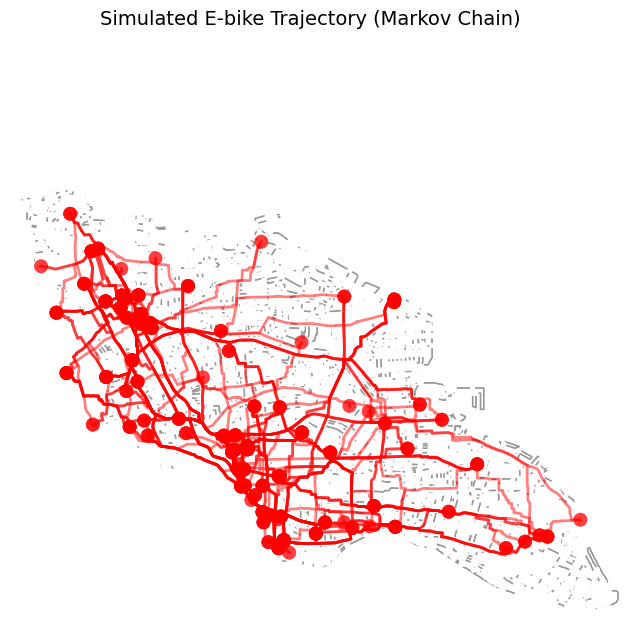

In [23]:
visualize_trajectory(graph, simulation_results[('summer', 'morning_peak')]['trajectory'])

By running a batch of simulations across multiple scenarios, we are able to generate simulation of a e-bike's trajectory over a full day (288 steps, 5-minute intervals). During each step, the bike moves from its current location to the next, guided by the adjusted probability matrix that accounts for distance, seasonality, time-of-day effects, and environmental location type.

The plotted graph shows a complete simulation of a selected e-bike's movement across the city streets, with red lines connecting the nodes the bike visits sequentially. This provides a clear and realistic visualization of the simulated bike journey through the city over time.

Overall, this part blends in geographic constraints, temporal demand patterns, and location-specific environmental effects into our model, allowing us to do a simple simulation of an individual e-bike's route movement. It moves beyond simple random walks to create a dynamic, data-driven, seasonally and temporally sensitive model of how e-bikes might move through an urban environment like Nantong.


## 24 hour transition matrix

In this section, we created a set of 24 hourly transition matrices to model how e-bike movement probabilities change across different hours of the day. The goal is to simulate the fact that bike movement demand with a deeper focus on the time, with higher activity during commute hours like the morning and evening peaks.

In [24]:
# Base Transition Matrix (initial probabilities)
base_transition_matrix = np.random.rand(100, 100)
base_transition_matrix = base_transition_matrix / base_transition_matrix.sum(axis=1, keepdims=True)

# Hourly demand factors
hourly_demand_factors = np.array([
    0.5, 0.4, 0.3, 0.3, 0.4, 0.6,  # 0-5 AM (low)
    1.2, 1.5, 1.3,                 # 6-8 AM (morning peak)
    1.0, 0.9, 0.8, 0.8, 0.7, 0.7,  # 9-14 PM (midday baseline)
    0.9, 1.2, 1.5,                 # 15-17 PM (evening peak)
    1.2, 1.0, 0.8, 0.7, 0.6, 0.5   # 18-23 PM (decreasing to night)
])

# Generate 24 matrices
transition_matrices_per_hour = []

for t in range(24):
    demand_factor = hourly_demand_factors[t]
    
    # Add a little random noise (~ ±5% variation)
    noise = np.random.normal(1.0, 0.05, base_transition_matrix.shape)
    
    # Apply demand and noise
    adjusted_matrix = base_transition_matrix * demand_factor * noise
    
    # Ensure no negative values
    adjusted_matrix = np.clip(adjusted_matrix, 0, None)
    
    # Normalize rows to sum to 1 (Markov property)
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    
    transition_matrices_per_hour.append(adjusted_matrix)



The process begins by generating a base transition matrix with random initial probabilities between 100 parking nodes. This base matrix is normalized so that the sum of probabilities across each row equals one, following the Markov property. To reflect daily demand variation, I defined a set of hourly demand factors: low demand at night and early morning, a significant increase during the morning peak (6 AM to 8 AM), moderate baseline activity during midday, another peak in the evening (3 PM to 5 PM), and a gradual slowdown into the night.

For each hour (from 0 to 23), the base transition matrix is adjusted by multiplying it with the corresponding hourly demand factor along with a small random noise (~5% variation) to simulate natural randomness. After adjustment, the matrix is clipped to remove negative values and renormalized to maintain the Markov property.

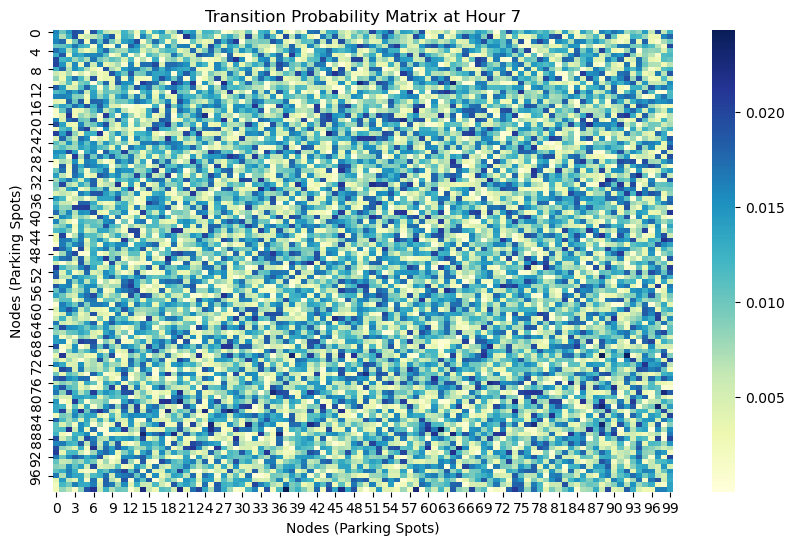

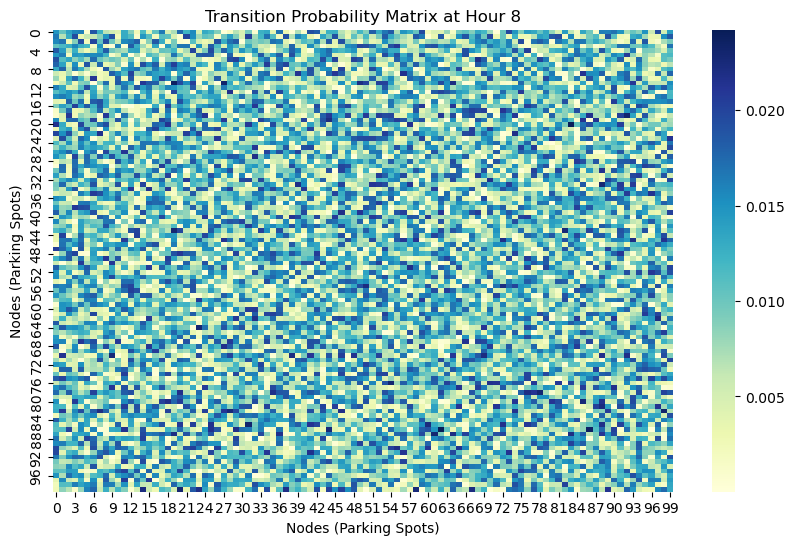

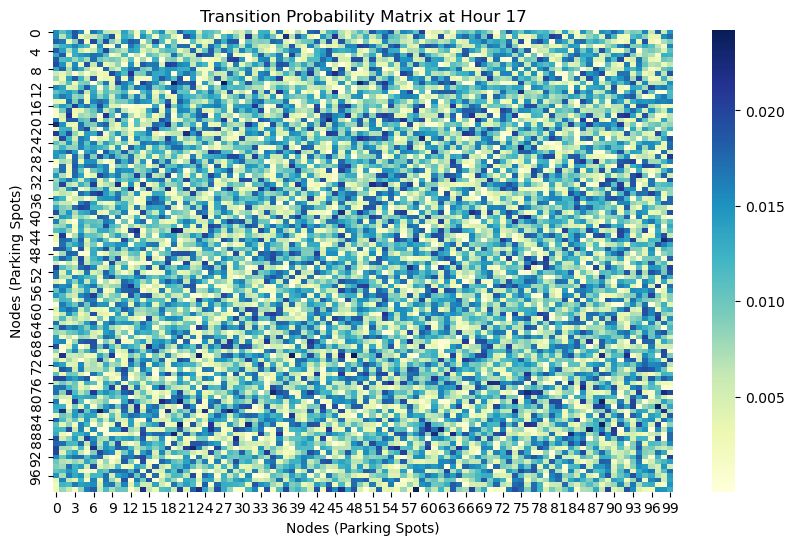

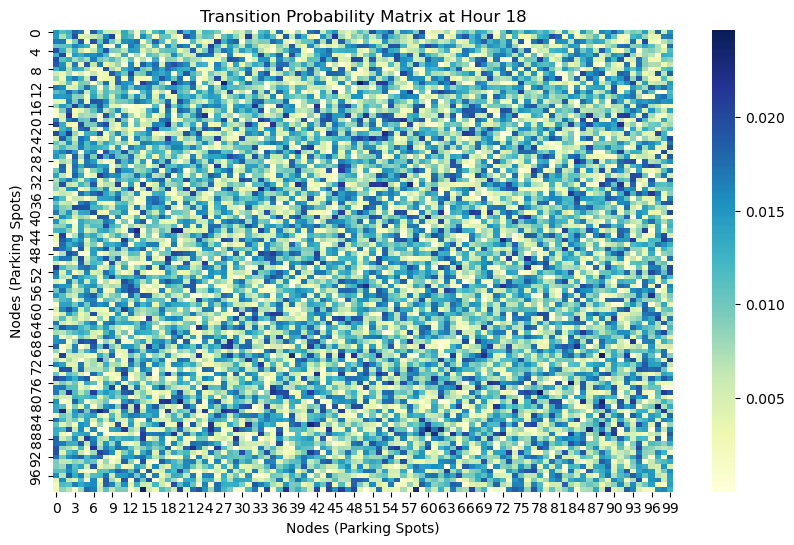

In [25]:
# Plot a few hours to see how they change
for t in [7, 8, 17, 18]:  # morning/evening peaks
    plt.figure(figsize=(10, 6))
    sns.heatmap(pd.DataFrame(transition_matrices_per_hour[t]), cmap="YlGnBu")
    plt.title(f"Transition Probability Matrix at Hour {t}")
    plt.xlabel("Nodes (Parking Spots)")
    plt.ylabel("Nodes (Parking Spots)")
    plt.show()

I visualized the results by plotting the transition probability matrices at selected hours — specifically 7 AM, 8 AM, 5 PM (17), and 6 PM (18), which correspond to the morning and evening peak periods. The heatmaps show the movement probabilities between nodes at these busy times. Visually, the matrices remain fairly dense and uniform because the original transition was random, but minor intensity differences across the heatmaps reflect the changes brought by hourly demand factors and noise.

Instead of assuming that movement probabilities are constant, it now adapting time factors to reflect higher mobility during commuting hours and lower mobility at night. Even though the matrices still appear visually similar due to the starting random distribution, this method allows future improvements like biasing transitions based on distance, location types, or real empirical demand to become much more realistic.

## Bias Transition Matrix by Distance

In this section, the model is further enhanced by implementing distance-biased transition matrices to better reflect real-world biking behavior, where bikes are much more likely to move to nearby locations than to faraway ones. The process starts by constructing a distance-weighted matrix using the inverse of the distance between pairs of parking spots like we did before with single constant probability matrix. Closer nodes have higher weights, while nodes that are very far away or disconnected have a weight of zero. Each row of this matrix is normalized so that the sum of transition probabilities for each starting node equals one, satisfying the Markov property.

In [26]:
# distance_matrix (100x100)

# Initialize the weight matrix
distance_weight_matrix = np.zeros_like(distance_matrix)

for i in range(100):
    for j in range(100):
        if i != j and distance_matrix[i, j] != np.inf:
            distance_weight_matrix[i, j] = 1.0 / distance_matrix[i, j]  # Inverse of distance
        else:
            distance_weight_matrix[i, j] = 0  # No path or same node

# Normalize rows (so rows sum to 1)
distance_weight_matrix = distance_weight_matrix / distance_weight_matrix.sum(axis=1, keepdims=True)


C:\Users\Cyl20\AppData\Local\Temp\ipykernel_34560\201907327.py:14: RuntimeWarning: invalid value encountered in divide
  distance_weight_matrix = distance_weight_matrix / distance_weight_matrix.sum(axis=1, keepdims=True)


In [27]:
base_transition_matrix = distance_weight_matrix.copy()

In [28]:
transition_matrices_per_hour = []

for t in range(24):
    demand_factor = hourly_demand_factors[t]
    
    noise = np.random.normal(1.0, 0.05, base_transition_matrix.shape)
    
    
    adjusted_matrix = base_transition_matrix * demand_factor * noise
    adjusted_matrix = np.clip(adjusted_matrix, 0, None)
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    
    transition_matrices_per_hour.append(adjusted_matrix)

In [29]:
stay_probabilities_per_hour = np.array([
    0.8, 0.8, 0.8, 0.8, 0.7, 0.6,  # 0-5 AM (mostly idle)
    0.2, 0.1, 0.2,                 # 6-8 AM (morning rush)
    0.3, 0.4, 0.4, 0.4, 0.5, 0.5,  # 9-14 PM (midday steady)
    0.4, 0.3, 0.2,                 # 15-17 PM (evening rush)
    0.3, 0.5, 0.6, 0.7, 0.8, 0.8   # 18-23 PM (nighttime slow down)
])

transition_matrices_per_hour_stay = []

for hour in range(24):
    matrix = transition_matrices_per_hour[hour].copy()
    stay_probability = stay_probabilities_per_hour[hour]
    
    # Add stay probability to diagonals
    np.fill_diagonal(matrix, matrix.diagonal() + stay_probability)
    
    # Re-normalize rows
    matrix = matrix / matrix.sum(axis=1, keepdims=True)
    
    transition_matrices_per_hour_stay.append(matrix)

In [30]:
# Simulation parameters
num_hours = 24
steps_per_hour = 4   # Assume each hour has 4 steps (e.g., 15 min interval)

total_steps = num_hours * steps_per_hour

# Start at a random node
current_node = random.choice(range(100))  # Index (not node id)
trajectory = [current_node]

for step in range(total_steps):
    hour = step // steps_per_hour  # Which hour we are in
    matrix = transition_matrices_per_hour_stay[hour]
    
    probs = matrix[current_node]
    next_node = np.random.choice(range(100), p=probs)
    
    trajectory.append(next_node)
    current_node = next_node

This distance-biased matrix then becomes the new base transition matrix. To incorporate daily demand fluctuations, the model applies the same set of hourly demand factors as before, slightly adjusting each hour's matrix with random noise to simulate natural randomness. This produces 24 hourly transition matrices that now not only respect hourly demand changes but are also inherently biased by physical proximity.

Building on this, I have also incorperated stay probabilities — the probability that a bike remains at its current location rather than moving to another node. Stay probabilities vary depending on the time of day: they are higher during off-peak hours (e.g., early morning or late night) and lower during rush hours when bikes are more actively moving. For each hour, the stay probability is added to the diagonal of the matrix (representing staying at the same node), and the rows are re-normalized.

[[0.16666667 0.00875806 0.00336978 ... 0.00270406 0.00983228 0.00270161]
 [0.01106048 0.16666667 0.00409355 ... 0.00610265 0.01000426 0.00622205]
 [0.00559537 0.00504035 0.16666667 ... 0.00427845 0.00762782 0.00267997]
 ...
 [0.00390414 0.00555648 0.00325247 ... 0.16666667 0.00412118 0.00358309]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.00741013 0.0103258  0.00463576 ... 0.0080434  0.00685033 0.16666667]]


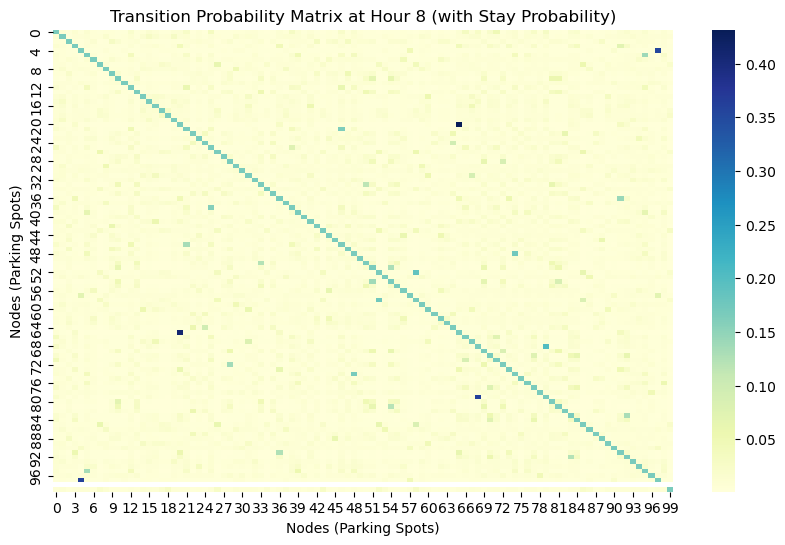

In [31]:
hour = 8  # 8AM
matrix_at_8am = transition_matrices_per_hour_stay[hour]
print(matrix_at_8am)
plt.figure(figsize=(10, 6))
sns.heatmap(matrix_at_8am, cmap="YlGnBu")
plt.title(f"Transition Probability Matrix at Hour {hour} (with Stay Probability)")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()

The e-bike movement is then simulated across a full 24-hour period with 15-minute time steps (totaling 96 steps). At each step, the bike’s movement decision is based on the corresponding hour’s stay-adjusted transition matrix. The resulting simulation captures realistic behaviors, where bikes may either stay in place or move to nearby nodes, and the likelihood of movement varies throughout the day.

With this approach, we can visualize that the transition matrix is representing more toward the realistic situation of e-bike movement and demand compare to the matrices before. The transition matrix at 8 AM for example (during the morning rush) clearly shows a strong diagonal pattern, representing a high chance for bikes to stay at their current location, but also some off-diagonal lighter areas where bikes are moving between nodes. This more realistic transition structure reflects both geographical constraints (nearby preference) and time-dependent behavior (rush-hour movement).

#### Factors considered
- Movement tendency --> Based on distance
- Demand intensity -->	Based on hour-of-day factors
- Stay behavior	--> Varies by time of day

In [32]:
# # Create a folder to save the CSV files
# output_folder = "24_hour_transition_matrices_csv"
# os.makedirs(output_folder, exist_ok=True)  # Create folder if not exist

# # Save each matrix
# for hour, matrix in enumerate(transition_matrices_per_hour_stay):
#     df = pd.DataFrame(matrix)
#     file_path = os.path.join(output_folder, f"transition_matrix_hour_{hour:02d}.csv")
#     df.to_csv(file_path, index=False)

# print("All 24 matrices saved successfully in the 'transition_matrices_csv' folder!")

## Heatmap Visualization 
In this section, we want to simulate the movement of many e-bikes across the 100 parking spots and visualize how the distribution of e-bikes evolves every 15 minutes. We will generate the overall number of e-bikes at time t by aggregating the transitioned distribution matrix with an initial random e-bike distribution matrix. Still, we will be updating these matrices every 15 minutes. We will also be assuming that the total number of e-bikes currently in the city is 500. These inputs are always adjustable for future analysis and simulation. 

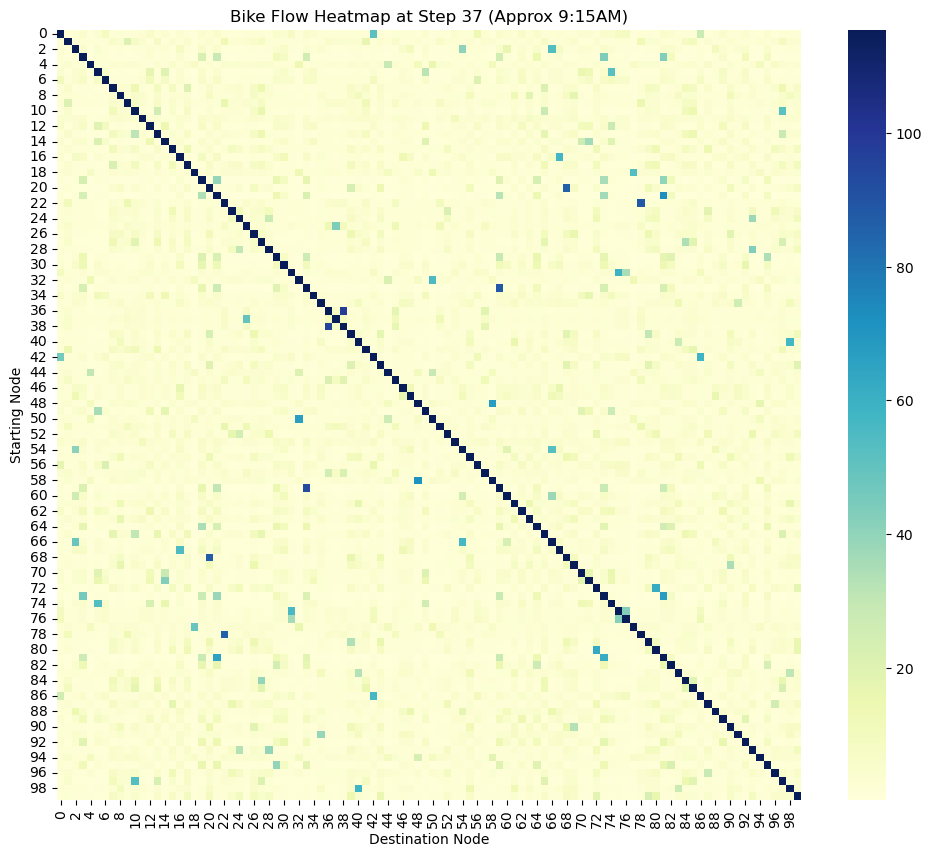

In [33]:
# Load Transition Matrices 
transition_matrices_per_hour = []

folder_path = "24_hour_transition_matrices_csv"

for hour in range(24):
    file_path = os.path.join(folder_path, f"transition_matrix_hour_{hour:02d}.csv")
    matrix = pd.read_csv(file_path).values  # Read CSV and convert to numpy array
    transition_matrices_per_hour.append(matrix)

# Initialize Bike Distribution 
np.random.seed(42)
num_nodes = 100
num_bikes = 500

# Randomly assign bikes
initial_distribution = np.random.multinomial(num_bikes, [1/num_nodes]*num_nodes)

# Simulation Settings 
steps_per_hour = 4   # 15 min per step
num_steps = 24 * steps_per_hour
bike_distributions = [initial_distribution.copy()]  # List to record bike distributions

current_distribution = initial_distribution.copy()

# Run Simulation 
for step in range(num_steps):
    hour = step // steps_per_hour  # Which hour we are in (0-23)
    transition_matrix = transition_matrices_per_hour[hour]

    # Update distribution
    new_distribution = current_distribution @ transition_matrix
    bike_distributions.append(new_distribution)

    current_distribution = new_distribution

# Pick a Time to Visualize 
# Example: Step 37 = 9:15 AM
selected_step = 37
selected_distribution = bike_distributions[selected_step]

# Create the Heatmap Data 
# We want a matrix where entry (i,j) = bikes moving from i to j
hour = selected_step // steps_per_hour
transition_matrix = transition_matrices_per_hour[hour]

flow_matrix = np.outer(selected_distribution, transition_matrix)  # outer product

# flow_matrix[i,j] = bikes at i * probability from i -> j
flow_matrix = flow_matrix.sum(axis=0)  # sum movements across all sources

# Reshape to (100 x 100)
flow_matrix = np.reshape(flow_matrix, (num_nodes, num_nodes))

# --- Plot the Heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(flow_matrix, cmap="YlGnBu")
plt.title(f"Bike Flow Heatmap at Step {selected_step} (Approx 9:15AM)")
plt.xlabel("Destination Node")
plt.ylabel("Starting Node")
plt.show()

Above heatmap represents the number of e-bikes at time t=37, which is approximately 9:15AM, at different node locations (e-bike parking spots). 

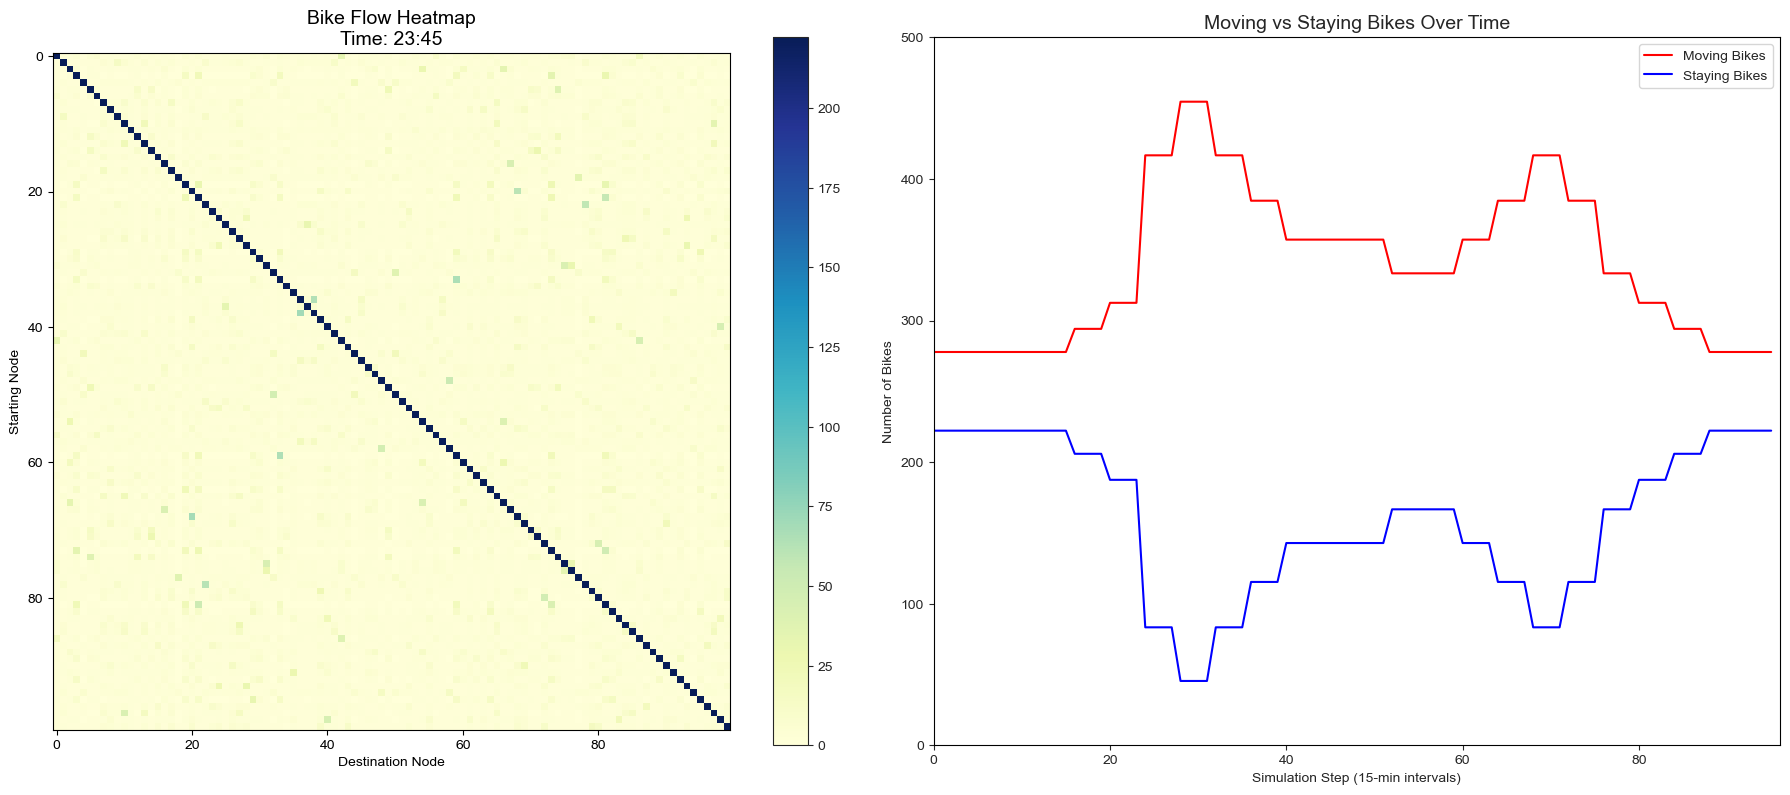

In [43]:
import matplotlib.animation as animation

num_nodes = 100
steps_per_hour = 4
num_steps = 24 * steps_per_hour

# Precompute Movement/Stay Info
stay_counts = []
move_counts = []

for frame in range(num_steps):
    distribution = bike_distributions[frame]
    hour = frame // steps_per_hour
    transition_matrix = transition_matrices_per_hour[hour]
    
    stay_probs = np.diag(transition_matrix)
    move_probs = transition_matrix.sum(axis=1) - stay_probs

    stay = np.sum(distribution * stay_probs)
    move = np.sum(distribution * move_probs)
    
    stay_counts.append(stay)
    move_counts.append(move)

# Initialize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

distribution = bike_distributions[0]
hour = 0
transition_matrix = transition_matrices_per_hour[hour]
flow_matrix = np.outer(distribution, transition_matrix)
flow_matrix = flow_matrix.sum(axis=0).reshape(num_nodes, num_nodes)

# Create Static Heatmap 
sns.set_style("white")
heatmap = ax1.imshow(flow_matrix, cmap="YlGnBu", vmin=0, vmax=np.max(flow_matrix))
cbar = fig.colorbar(heatmap, ax=ax1)
ax1.set_title("Bike Flow Heatmap", fontsize=14)
ax1.set_xlabel("Destination Node")
ax1.set_ylabel("Starting Node")

# Create Static Line Plot
line1, = ax2.plot([], [], label="Moving Bikes", color='red')
line2, = ax2.plot([], [], label="Staying Bikes", color='blue')
ax2.set_xlim(0, num_steps)
ax2.set_ylim(0, max(max(stay_counts), max(move_counts)) * 1.1)
ax2.set_title("Moving vs Staying Bikes Over Time", fontsize=14)
ax2.set_xlabel("Simulation Step (15-min intervals)")
ax2.set_ylabel("Number of Bikes")
ax2.legend()

# Update Function 
def update(frame):
    # Update Heatmap
    distribution = bike_distributions[frame]
    hour = frame // steps_per_hour
    transition_matrix = transition_matrices_per_hour[hour]
    flow_matrix = np.outer(distribution, transition_matrix)
    flow_matrix = flow_matrix.sum(axis=0).reshape(num_nodes, num_nodes)
    
    heatmap.set_data(flow_matrix)
    
    step_hour = frame // 4
    step_minute = (frame % 4) * 15
    ax1.set_title(f"Bike Flow Heatmap\nTime: {step_hour:02d}:{step_minute:02d}", fontsize=14)
    
    # Update Line Plot
    ax2.clear()
    ax2.plot(range(frame+1), move_counts[:frame+1], label="Moving Bikes", color='red')
    ax2.plot(range(frame+1), stay_counts[:frame+1], label="Staying Bikes", color='blue')
    ax2.set_xlim(0, num_steps)
    ax2.set_ylim(0, max(max(stay_counts), max(move_counts)) * 1.1)
    ax2.set_title("Moving vs Staying Bikes Over Time", fontsize=14)
    ax2.set_xlabel("Simulation Step (15-min intervals)")
    ax2.set_ylabel("Number of Bikes")
    ax2.legend()

# Animation
ani = animation.FuncAnimation(fig, update, frames=num_steps, interval=200)

# Saving as GIF
ani.save("bike_flow_animation_fixed.gif", writer="pillow", fps=5)

plt.tight_layout()
plt.show()

For better visualization, we created a dynamic animation to visualize how shared e-bikes move and distribute across a city's parking spots throughout a 24-hour simulation. The animation simultaneously presents two synchronized views: on the left panel, a heatmap displays the evolving flow of bikes between different parking spots, while on the right panel, a line plot tracks the number of bikes actively moving versus staying idle over time, updated at every 15-minute interval.

The observed animation shows that the heatmap remains relatively static throughout the 24-hour simulation, with minimal visible changes in the flow distribution across parking nodes (only gradient changes for those indexes that are not 0). The primary reason for this behavior is the limited number of nodes (only 100 parking locations) combined with the transition matrix construction method. Since the transition probabilities are heavily biased by inverse distance, bikes predominantly move to nearby nodes, and movements to faraway nodes are extremely rare. As a result, the transition matrices are sparse, and movement between most pairs of nodes remains close to zero.

The second observation pertains to the moving and staying bike count plot. The animation demonstrates an perfectly symmetric pattern: as the number of moving bikes increases, the number of staying bikes decreases proportionally, and vice versa. This symmetry is not realistic when compared to actual shared-bike system behavior. This is mainly caused by how we applied stay probabilities. Stay probabilities were assigned uniformly across all nodes at each time period, without differentiation based on location type or demand intensity. For future adjustment, we should vary the stay rates by different factors such as location type or other random user behaviors. 

#### For Future Improvements
First, increasing the number of nodes from 100 to the actual spot number (around 2000 in Nantong City) would create more possible pathways, resulting in a more varied and realistic e-bike route flow structure. More nodes allow us to generate a broader distribution, helping the heatmap capture more dynamics.

Second, each node should be assigned a location type such as business district, residential area, subway station, or university accordingly. Stay and move probabilities should then vary according to the location type. For example, bikes in business areas during working hours should have a lower stay probability compared to residential areas at night.

Third, the distance bias in the transition matrix could be adjusted to allow a moderate probability of mid-distance movements. Currently, nodes with far distances have almost zero probability, leading to local clustering and little network-wide spread.

Last, the model should incorporate real-time-dependent local demand shifts. The factor weights we use are constant and assumed. We should further do analyze (training models to get weight vectors) for weight values and use a more precise weight value for each time, location, and season factor. 

#### Conclusion
The current simulation successfully demonstrates a initial foundational Markov-based bike movement model that incorporates hourly demand patterns. However, to better capture realistic urban shared-bike dynamics, the model would improve significantly from increasing node density, differentiating location types, modifying the transition bias, and introducing stochastic variation. Implementing these improvements would result in a simulation that better reflects the complexity and variability of real-world shared mobility systems.